In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

plt.style.use('ggplot')

I0000 00:00:1774101049.246839   30993 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774101049.247215   30993 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774101049.278230   30993 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774101049.931080   30993 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [4]:
df = pd.read_csv('btc.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 287085 entries, 0 to 287084
Data columns (total 12 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Open time                     287084 non-null  str    
 1   Open                          287085 non-null  float64
 2   High                          287085 non-null  float64
 3   Low                           287085 non-null  float64
 4   Close                         287085 non-null  float64
 5   Volume                        287085 non-null  float64
 6   Close time                    287084 non-null  str    
 7   Quote asset volume            287085 non-null  float64
 8   Number of trades              287085 non-null  int64  
 9   Taker buy base asset volume   287085 non-null  float64
 10  Taker buy quote asset volume  287085 non-null  float64
 11  Ignore                        287085 non-null  int64  
dtypes: float64(8), int64(2), str(2)
memory usage: 26.3 MB


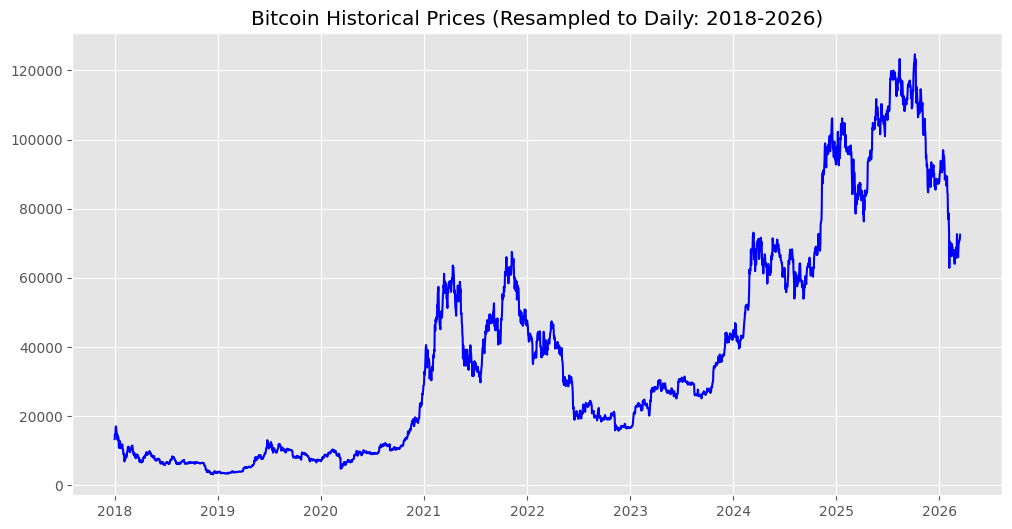

New Training data size: 2631 days
New Testing data size: 365 days


In [6]:
# Load the specific BTC dataset
df = pd.read_csv('btc.csv')

# 2. Rename the specific time column to 'Date' to match our architecture
df.rename(columns={'Open time': 'Date'}, inplace=True)

# 3. Filter down to just the columns we need
df = df[['Date', 'Close']]

# 4. Parse dates and set the index
df['Date'] = pd.to_datetime(df['Date']) 
df = df.sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)

# 5. CRITICAL STEP: Resample 15-minute data into Daily data ('D')
# We use .last() to get the final closing price of each day
df = df.resample('D').last()

# 6. Fill any days where the exchange might have been offline
df = df.ffill()

# Plot to verify
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], color='blue')
plt.title('Bitcoin Historical Prices (Resampled to Daily: 2018-2026)')
plt.show()

test_size = 365 
train_data = df[:-test_size]
test_data = df[-test_size:]

print(f"New Training data size: {len(train_data)} days")
print(f"New Testing data size: {len(test_data)} days")

In [7]:
print("--- Training Random Forest ---")

# Create a supervised learning dataset (using lag features)
def create_rf_features(data, lookback=7):
    X, y = [], []
    prices = data['Close'].values
    for i in range(len(prices) - lookback):
        X.append(prices[i:(i + lookback)])
        y.append(prices[i + lookback])
    return np.array(X), np.array(y)

X_train_rf, y_train_rf = create_rf_features(train_data)
X_test_rf, y_test_rf = create_rf_features(pd.concat([train_data.iloc[-7:], test_data]))

# Train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_rf, y_train_rf)

# Predict
rf_predictions = rf_model.predict(X_test_rf)
rf_rmse = root_mean_squared_error(test_data['Close'], rf_predictions)
print(f"Random Forest RMSE: {rf_rmse:.2f}")

--- Training Random Forest ---
Random Forest RMSE: 7861.26


In [8]:
from xgboost import XGBRegressor

print("--- Training XGBoost ---")

# We are re-using the X_train_rf and X_test_rf features you ALREADY 
# generated in the Random Forest cell. No new data prep needed!

# Initialize and train the XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train_rf, y_train_rf)

# Predict
xgb_predictions = xgb_model.predict(X_test_rf)

# Calculate Error
xgb_rmse = root_mean_squared_error(test_data['Close'], xgb_predictions)
print(f"XGBoost RMSE: {xgb_rmse:.2f}")

--- Training XGBoost ---
XGBoost RMSE: 7100.73


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import root_mean_squared_error
import numpy as np

print("--- Training LSTM ---")

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_data)
scaled_test = scaler.transform(test_data)

def create_lstm_sequences(data, lookback=60):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

lookback = 60
lstm_test_inputs = np.vstack((scaled_train[-lookback:], scaled_test))

X_train_lstm, y_train_lstm = create_lstm_sequences(scaled_train, lookback)
X_test_lstm, y_test_lstm = create_lstm_sequences(lstm_test_inputs, lookback)

X_train_lstm = np.reshape(X_train_lstm, (X_train_lstm.shape[0], X_train_lstm.shape[1], 1))
X_test_lstm = np.reshape(X_test_lstm, (X_test_lstm.shape[0], X_test_lstm.shape[1], 1))

# --- UPDATED ARCHITECTURE ---
lstm_model = Sequential()

# 1. Added explicit Input layer to fix the warning
lstm_model.add(Input(shape=(X_train_lstm.shape[1], 1)))

# 2. Added Dropout layers to force the model to keep learning
lstm_model.add(LSTM(units=50, return_sequences=True))
lstm_model.add(Dropout(0.2)) 

lstm_model.add(LSTM(units=50))
lstm_model.add(Dropout(0.2))

lstm_model.add(Dense(units=1))

# 3. Lowered learning rate so the loss drops more gradually
custom_optimizer = Adam(learning_rate=0.0005) 

lstm_model.compile(optimizer=custom_optimizer, loss='mean_squared_error')

# Increased epochs slightly since it's learning slower now
lstm_model.fit(X_train_lstm, y_train_lstm, epochs=15, batch_size=32, verbose=1)

# Predict and inverse transform
lstm_preds_scaled = lstm_model.predict(X_test_lstm)
lstm_predictions = scaler.inverse_transform(lstm_preds_scaled)

lstm_rmse = root_mean_squared_error(test_data['Close'], lstm_predictions)
print(f"LSTM RMSE: {lstm_rmse:.2f}")

--- Training LSTM ---
Epoch 1/15


E0000 00:00:1774101343.769626   30993 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0135
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0024
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0020
Epoch 4/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0020
Epoch 5/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0018
Epoch 6/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0017
Epoch 7/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0016
Epoch 8/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.0017
Epoch 9/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0014
Epoch 10/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 0.0015
Epoch 11/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0014
Epoch 12/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0014
Epoch 13/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0013
Epoch 14/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 0.0014
Epoch 15/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0013
12/12 ━━━━━━━━━

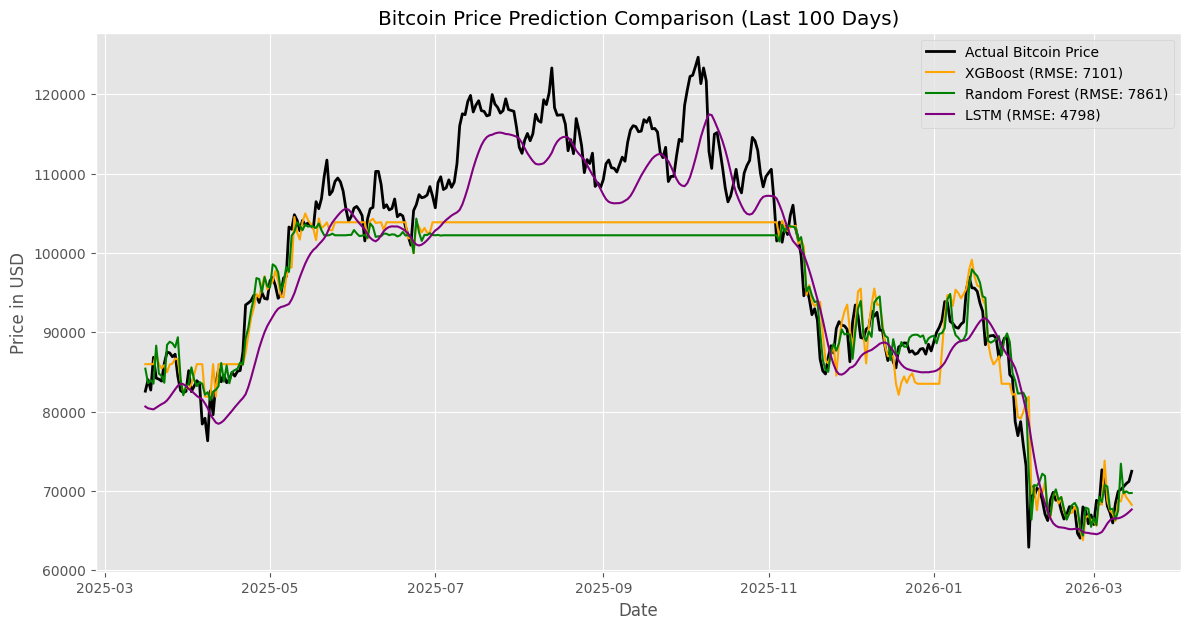

In [10]:
plt.figure(figsize=(14, 7))

# Plot Actual Prices
plt.plot(test_data.index, test_data['Close'], label='Actual Bitcoin Price', color='black', linewidth=2)

# Plot Predictions
plt.plot(test_data.index, xgb_predictions, label=f'XGBoost (RMSE: {xgb_rmse:.0f})', color='orange')

plt.plot(test_data.index, rf_predictions, label=f'Random Forest (RMSE: {rf_rmse:.0f})', color='green')
plt.plot(test_data.index, lstm_predictions, label=f'LSTM (RMSE: {lstm_rmse:.0f})', color='purple')

plt.title('Bitcoin Price Prediction Comparison (Last 100 Days)')
plt.xlabel('Date')
plt.ylabel('Price in USD')
plt.legend()
plt.show()

In [11]:
import joblib

print("--- Exporting ALL Models & Scaler ---")

joblib.dump(scaler, 'bitcoin_scaler.pkl')
print("Saved: bitcoin_scaler.pkl")

lstm_model.save('bitcoin_lstm.keras')
print("Saved: bitcoin_lstm.keras")

joblib.dump(rf_model, 'bitcoin_rf.pkl')
print("Saved: bitcoin_rf.pkl")

xgb_model.save_model('bitcoin_xgb.json')
print("Saved: bitcoin_xgb.json")

print("\nAll models exported successfully! Ready for the API.")

--- Exporting ALL Models & Scaler ---
Saved: bitcoin_scaler.pkl
Saved: bitcoin_lstm.keras
Saved: bitcoin_rf.pkl
Saved: bitcoin_xgb.json

All models exported successfully! Ready for the API.
